## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import time

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv("./data/titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.


In [8]:
#limpieza de columnas con nulos
df_limpio = df.drop(["deck", "embark_town", "alive", "class", "who", "adult_male"], axis = 1)


In [ ]:
#imputación de nulos
df_limpio["age"] = df_limpio['age'].fillna(
    df_limpio['age'].median()
)

moda_embarked = df_limpio["embarked"].mode()[0]
df_limpio["embarked"] = df_limpio["embarked"].fillna(
    moda_embarked
)

In [11]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [15]:
#Codificación
le = LabelEncoder()

# Sex: Binario (0 o 1)
df_limpio["sex"] = le.fit_transform(df_limpio['sex'])

# Embarked: One-Hot Encoding (C, Q, S se convierten en columnas separadas)
df_limpio = pd.get_dummies(
    df_limpio,
    columns=['embarked'],
    drop_first=True)


In [16]:
df_limpio.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,False,True
1,1,1,0,38.0,1,0,71.2833,False,False,False
2,1,3,0,26.0,0,0,7.9250,True,False,True
3,1,1,0,35.0,1,0,53.1000,False,False,True
4,0,3,1,35.0,0,0,8.0500,True,False,True


In [21]:
#Escalado
X = df_limpio.drop(["survived"], axis = 1)
y = df_limpio["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = X_test.columns)

print(f"Forma de X_train_scaled: {X_train_scaled_df.shape}")

Forma de X_train_scaled: (712, 9)


In [22]:
X_train_scaled_df.head()

,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,-1.614136,0.724310,1.253641,-0.470722,-0.479342,-0.078684,0.812203,-0.303355,0.592489
1,-0.400551,0.724310,-0.477284,-0.470722,-0.479342,-0.377145,0.812203,-0.303355,0.592489
2,0.813034,0.724310,0.215086,-0.470722,-0.479342,-0.474867,0.812203,-0.303355,0.592489
3,0.813034,0.724310,-0.246494,0.379923,-0.479342,-0.476230,-1.231219,-0.303355,0.592489
4,0.813034,-1.380624,-1.785093,2.931860,2.048742,-0.025249,-1.231219,-0.303355,0.592489


---

# Entrenamiento optimizado con Random Forest

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state = 42)

param_grid_rf = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 10, 20],
    'min_samples_split':[2, 5, 10],
    'max_features' : ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator= rf,
    param_grid = param_grid_rf,
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_rf.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=1)

In [24]:
print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Mejor accuracy en CV: {grid_rf.best_score_:.4f}")

# Guardamos el mejor modelo para la comparativa final
best_rf_model = grid_rf.best_estimator_

Mejores parámetros RF: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
Mejor accuracy en CV: 0.8258


# Entrenamiento con DL

In [ ]:

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(max_iter = 2000, random_state = 42)

param_grid_mlp ={
    'hidden_layer_sizes':[
        (100,),             # Default: 1 capa de 100 neuronas
        (50,),              # 1 capa más pequeña
        (100, 50),          # 2 capas (cumple requisito >1 capa)
        (50, 25, 10)        # 3 capas (límite máximo permitido)
    ],
    'activation': ['relu', 'tanh'],       # Default: relu
    'solver': ['adam', 'sgd'],            # Default: adam
    'alpha': [0.0001, 0.001, 0.01],       # Default: 0.0001 (Regularización L2)
    'learning_rate': ['constant', 'adaptive'] # Default: constant
}

grid_mlp = GridSearchCV(
    estimator = mlp,
    param_grid = param_grid_mlp,
    cv = 5,
    n_jobs = -1,
    verbose=1
)

grid_mlp.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=2000, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(100,), (50,), (100, 50),
                                                (50, 25, 10)],
                         'learning_rate': ['constant', 'adaptive'],
                         'solver': ['adam', 'sgd']},
             verbose=1)

In [26]:
print(f"Mejores parámetros MLP: {grid_mlp.best_params_}")
print(f"Mejor accuracy en CV: {grid_mlp.best_score_:.4f}")

# Guardamos el mejor modelo
best_mlp_model = grid_mlp.best_estimator_

Mejores parámetros MLP: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}
Mejor accuracy en CV: 0.8202


---

# Comparativa de modelos

In [27]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Recuperamos las mejores configuraciones
best_rf = grid_rf.best_estimator_
best_mlp = grid_mlp.best_estimator_

def tiempo():
    return time.time()

#Evaluación RF
start_time = tiempo()
best_rf.fit(X_train_scaled, y_train)
rf_time = tiempo() - start_time
y_pred_rf = best_rf.predict(X_test_scaled)

#Evaluación MLP
start_time = tiempo()
best_mlp.fit(X_train_scaled, y_train)
mlp_time = tiempo() - start_time
y_pred_mlp = best_mlp.predict(X_test_scaled)



In [28]:
for nombre, preds, tiempo in [("Random Forest", y_pred_rf, rf_time), ("MLP (Deep Learning)", y_pred_mlp, mlp_time)]:
    print(f"\nModelo: {nombre}")
    print(f"Tiempo de entrenamiento: {tiempo:.5f} segundos")
    print(f"Accuracy (Test): {accuracy_score(y_test, preds):.4f}")
    print(f"Precision (Media): {precision_score(y_test, preds, average='macro'):.4f}")
    print(f"Recall (Media):    {recall_score(y_test, preds, average='macro'):.4f}")


Modelo: Random Forest
Tiempo de entrenamiento: 0.08349 segundos
Accuracy (Test): 0.8380
Precision (Media): 0.8424
Recall (Media):    0.8220

Modelo: MLP (Deep Learning)
Tiempo de entrenamiento: 1.03560 segundos
Accuracy (Test): 0.8101
Precision (Media): 0.8106
Recall (Media):    0.7942


Rendimiento (Métricas): El Random Forest supera al MLP en todas las métricas clave. Con un Accuracy del 83.80% frente al 81.01% del MLP, el modelo de árboles demuestra mayor capacidad predictiva. Además, su Recall (82.20%) es superior, lo que indica que es mejor identificando a los supervivientes reales, minimizando los falsos negativos.

Eficiencia Computacional: La diferencia es drástica. El Random Forest entrena en 0.08 segundos, mientras que la red neuronal necesita 1.03 segundos (aprox. 12 veces más) para obtener un resultado peor. En un entorno productivo con millones de datos, esta diferencia de coste computacional haría inviable el MLP sin una justificación de mejora de rendimiento que aquí no existe.

Naturaleza de los datos: Al ser un dataset tabular y relativamente pequeño, los modelos de ensamble (como Random Forest) suelen capturar mejor las relaciones no lineales sin necesitar la cantidad masiva de datos que requiere el Deep Learning para brillar.

---

# Análisis del MLP



--- DETALLES DEL MODELO DE DEEP LEARNING (MLP) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



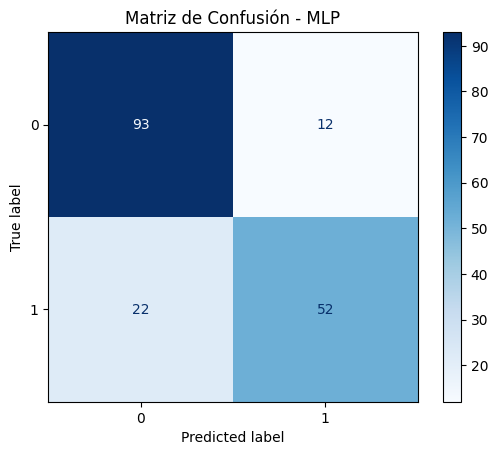

In [30]:
print("\n\n--- DETALLES DEL MODELO DE DEEP LEARNING (MLP) ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp))

# Matriz de confusión visual
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_mlp.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - MLP")
plt.show()

- Desempeño Global (Accuracy 81%):

    El modelo ha convergido correctamente, alcanzando un acierto del 81%. Esto significa que clasifica bien a 4 de cada 5 pasajeros. Es un resultado aceptable para una primera aproximación con Deep Learning, pero no supera al Random Forest.

- El problema del Recall en la Clase 1 (0.70):

    Este es el dato más crítico del reporte.

        Para la Clase 0 (No supervivientes), el modelo tiene un Recall del 0.89. Detecta muy bien a los fallecidos.

        Para la Clase 1 (Supervivientes), el Recall baja a 0.70.

        Significado práctico: El modelo está dejando escapar al 30% de los supervivientes. Tiene un sesgo hacia la clase mayoritaria (fallecidos), lo que genera muchos Falsos Negativos (predice que mueren personas que realmente sobrevivieron).

- Precisión (Precision 0.81 en ambas):

    Curiosamente, el modelo es bastante fiable cuando se "atreve" a predecir. Si dice que alguien sobrevive, tiene un 81% de probabilidad de acertar. El problema no es que se equivoque cuando predice "sobrevive", sino que se deja a muchos supervivientes sin detectar (peca de conservador).

Conclusión del Deep Learning:

    La red neuronal ha logrado generalizar, pero sufre para identificar correctamente la clase minoritaria (supervivientes) en comparación con el Random Forest, que obtuvo un Recall más equilibrado.